Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6895 - loss: nan - val_accuracy: 0.9990 - val_loss: nan
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9998 - loss: nan - val_accuracy: 0.9990 - val_loss: nan
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9997 - loss: nan - val_accuracy: 0.9990 - val_loss: nan
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9991 - loss: nan - val_accuracy: 0.9990 - val_loss: nan
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9996 - loss: nan - val_accuracy: 0.9990 - val_loss: nan
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9994 - loss: nan - val_accuracy: 0.9990 - val_loss: nan
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9995 - loss: nan - val_accuracy: 0.9990 - val_loss: nan
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9997 - loss: nan - val_accuracy: 0.9990 - val_loss: nan
Epoch 9/10
120/120 ━━━━━━━━━━━━━━━━

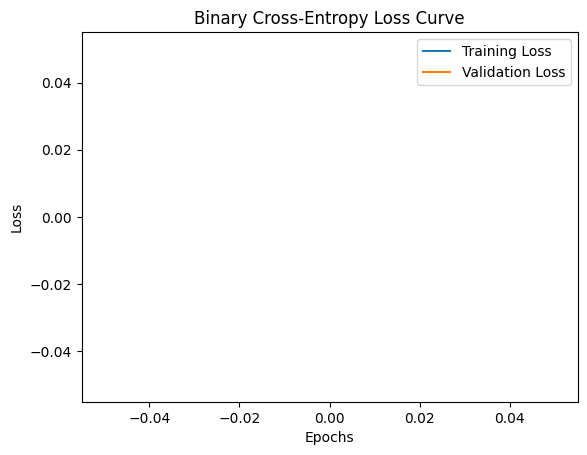

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


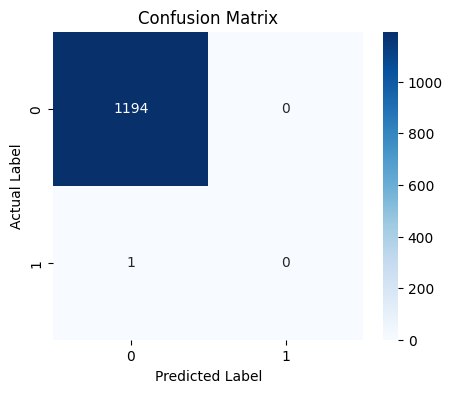

In [2]:
# =========================================
# CREDIT CARD FRAUD DETECTION USING KERAS
# 0 = Real Transaction, 1 = Fraud Transaction
# =========================================

# STEP 1: IMPORT REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# STEP 2: LOAD THE DATASET
# Load credit card fraud dataset
data = pd.read_csv("creditcard.csv")
# 'Class' column: 0 -> Real, 1 -> Fraud
X = data.drop("Class", axis=1)
y = data["Class"]

# STEP 3: FEATURE SCALING
# Scale input features to improve training
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# STEP 4: TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# STEP 5: BUILD NEURAL NETWORK MODEL
model = Sequential()
# Input layer + Hidden layer 1
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
# Hidden layer 2
model.add(Dense(8, activation='relu'))
# Output layer
# Sigmoid gives probability between 0 and 1
model.add(Dense(1, activation='sigmoid'))

# STEP 6: COMPILE THE MODEL
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',   # Best loss for binary classification
    metrics=['accuracy']
)

# STEP 7: TRAIN THE MODEL
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# STEP 8: PLOT LOSS FUNCTION CURVE
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Binary Cross-Entropy Loss Curve")
plt.legend()
plt.show()

# STEP 9: MODEL PREDICTION
# Get probability predictions
y_pred_prob = model.predict(X_test)

# STEP 10: APPLY THRESHOLD
threshold = 0.3   # Lower threshold to catch more frauds
# Convert probability to class: >threshold -> Fraud (1), else Real (0)
y_pred = (y_pred_prob > threshold).astype(int)

# STEP 11: CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()
